# SIT720 8.1D – Sydney Housing Price Prediction
**Student:** Rishi Harshadbhai Soni  
**Student ID:** s225445228

This notebook loads the project dataset, performs exploratory analysis, trains three regression models, evaluates them with 5-fold cross-validation, and investigates prediction errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Load and check the dataset

In [2]:
df = pd.read_csv('SIT720_8.1D_Recent_Sydney_Housing_120_Properties.csv')
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])
df['Sale_Month'] = df['Sale_Date'].dt.month
df['Sale_Year'] = df['Sale_Date'].dt.year
print('Shape:', df.shape)
display(df.head())
print('\nProperties by suburb:')
print(df['Suburb'].value_counts())
print('\nMissing values:')
print(df.isna().sum())

Shape: (120, 14)


,Record_ID,Address,Suburb,Postcode,Sale_Date,Sale_Price_AUD,Property_Type,Bedrooms,Bathrooms,Parking,Land_Area_sqm,Source,Sale_Month,Sale_Year
0,1,84-84a Duckmallois Avenue,Blacktown,2148,2026-09-19,1405000,House,6,3,3,701.0,https://www.domain.com.au/sold-listings/blackt...,9,2026
1,2,49 Pendant Avenue,Blacktown,2148,2026-09-18,980000,House,3,1,2,613.0,https://www.domain.com.au/sold-listings/blackt...,9,2026
2,3,199 Flushcombe Road,Blacktown,2148,2026-09-17,900000,House,3,1,3,556.0,https://www.domain.com.au/sold-listings/blackt...,9,2026
3,4,40 Stephen Street,Blacktown,2148,2026-09-17,1350000,House,5,3,3,338.0,https://www.domain.com.au/sold-listings/blackt...,9,2026
4,5,6 Oregon Street,Blacktown,2148,2026-09-16,1105000,House,3,1,3,739.0,https://www.domain.com.au/sold-listings/blackt...,9,2026



Properties by suburb:
Suburb
Blacktown        40
Balmain          40
Bellevue Hill    40
Name: count, dtype: int64

Missing values:
Record_ID          0
Address            0
Suburb             0
Postcode           0
Sale_Date          0
Sale_Price_AUD     0
Property_Type      0
Bedrooms           0
Bathrooms          0
Parking            0
Land_Area_sqm     52
Source             0
Sale_Month         0
Sale_Year          0
dtype: int64


## 2. Exploratory Data Analysis
I expected suburb, land area and bedrooms to be important predictors before modelling. Suburb represents different local markets, while land area and bedrooms give information about property size.

In [3]:
summary = df.groupby('Suburb')['Sale_Price_AUD'].agg(['count','mean','median','min','max']).round(0)
display(summary)
print('\nProperty types:')
print(df['Property_Type'].value_counts())

,count,mean,median,min,max
Suburb,,,,,
Balmain,40,2282700.0,2162500.0,655000,4650000
Bellevue Hill,40,4562162.0,1650000.0,550000,20000000
Blacktown,40,1120812.0,1077500.0,460000,1900000



Property types:
Property_Type
House                      72
Apartment / Unit / Flat    43
Townhouse                   4
Studio                      1
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

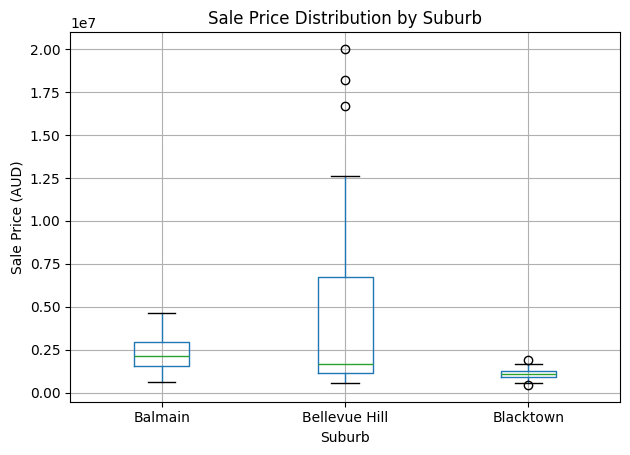

In [4]:
plt.figure(figsize=(8,5))
df.boxplot(column='Sale_Price_AUD', by='Suburb')
plt.suptitle('')
plt.title('Sale Price Distribution by Suburb')
plt.ylabel('Sale Price (AUD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

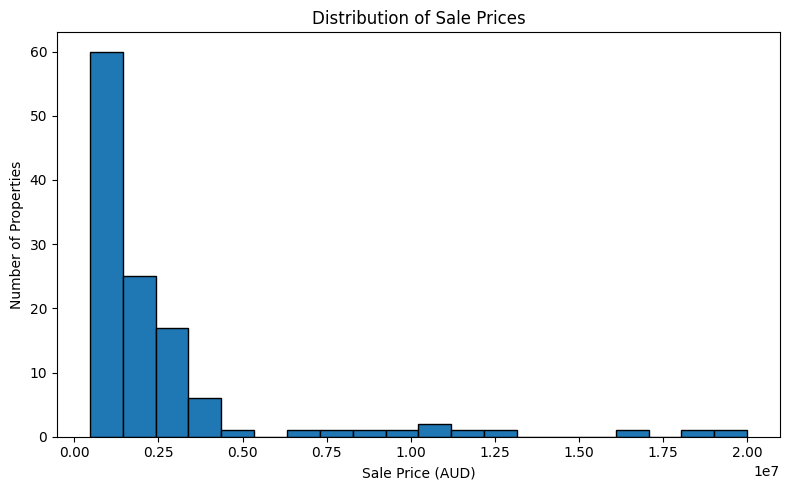

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df['Sale_Price_AUD'], bins=20, edgecolor='black')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price (AUD)')
plt.ylabel('Number of Properties')
plt.tight_layout()
plt.show()

## 3. Preprocessing and model evaluation
Categorical variables are one-hot encoded. Missing land-area values are imputed using the median. Three different regression approaches are compared using shuffled 5-fold cross-validation.

In [6]:
features = ['Suburb','Property_Type','Bedrooms','Bathrooms','Parking','Land_Area_sqm','Sale_Month']
X = df[features].copy()
y = df['Sale_Price_AUD'].copy()
numeric_features = ['Bedrooms','Bathrooms','Parking','Land_Area_sqm','Sale_Month']
categorical_features = ['Suburb','Property_Type']

def make_pipeline(model, scale_numeric=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    preprocessor = ColumnTransformer([
        ('num', Pipeline(numeric_steps), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ])
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

models = {
    'Linear Regression': make_pipeline(LinearRegression(), True),
    'Random Forest': make_pipeline(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)),
    'Gradient Boosting': make_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE))
}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows=[]
for name, model in models.items():
    result = cross_validate(model, X, y, cv=cv, scoring={'mae':'neg_mean_absolute_error','mse':'neg_mean_squared_error','r2':'r2'})
    rows.append({
        'Model': name,
        'MAE': -result['test_mae'].mean(),
        'RMSE': np.sqrt(-result['test_mse']).mean(),
        'Mean R2': result['test_r2'].mean()
    })
results = pd.DataFrame(rows).sort_values('MAE')
display(results.style.format({'MAE':'${:,.0f}','RMSE':'${:,.0f}','Mean R2':'{:.3f}'}))

,Model,MAE,RMSE,Mean R2
2,Gradient Boosting,"$611,279","$1,142,571",0.794
1,Random Forest,"$773,024","$1,438,050",0.782
0,Linear Regression,"$1,457,644","$1,941,298",0.307


The model with the lowest cross-validated MAE is used for the held-out error analysis below.

## 4. Held-out test set and error analysis

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
best_name = results.iloc[0]['Model']
best_model = models[best_name]
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)
print('Selected model:', best_name)
print(f'Test MAE: ${mean_absolute_error(y_test,pred):,.0f}')
print(f'Test RMSE: ${mean_squared_error(y_test,pred)**0.5:,.0f}')
print(f'Test R2: {r2_score(y_test,pred):.3f}')
error_table = df.loc[X_test.index, ['Address','Suburb','Property_Type','Bedrooms','Bathrooms','Parking','Land_Area_sqm','Sale_Price_AUD']].copy()
error_table['Predicted_Price'] = pred
error_table['Absolute_Error'] = np.abs(error_table['Sale_Price_AUD'] - error_table['Predicted_Price'])
top5 = error_table.sort_values('Absolute_Error', ascending=False).head(5)
display(top5.style.format({'Sale_Price_AUD':'${:,.0f}','Predicted_Price':'${:,.0f}','Absolute_Error':'${:,.0f}'}))

Selected model: Gradient Boosting
Test MAE: $410,448
Test RMSE: $735,263
Test R2: 0.537


,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Land_Area_sqm,Sale_Price_AUD,Predicted_Price,Absolute_Error
107,91 Birriga Road,Bellevue Hill,House,4,2,1,nan,"$4,000,000","$6,796,342","$2,796,342"
18,41 Dagmar Crescent,Blacktown,House,3,1,2,569.000000,"$880,000","$2,162,412","$1,282,412"
70,96 Rosser Street,Balmain,House,4,3,0,182.000000,"$3,150,000","$4,323,946","$1,173,946"
40,80 College Street,Balmain,House,5,2,1,334.000000,"$3,585,000","$2,572,336","$1,012,664"
65,10 Terry Street,Balmain,House,3,2,0,177.000000,"$3,312,000","$2,675,200","$636,800"


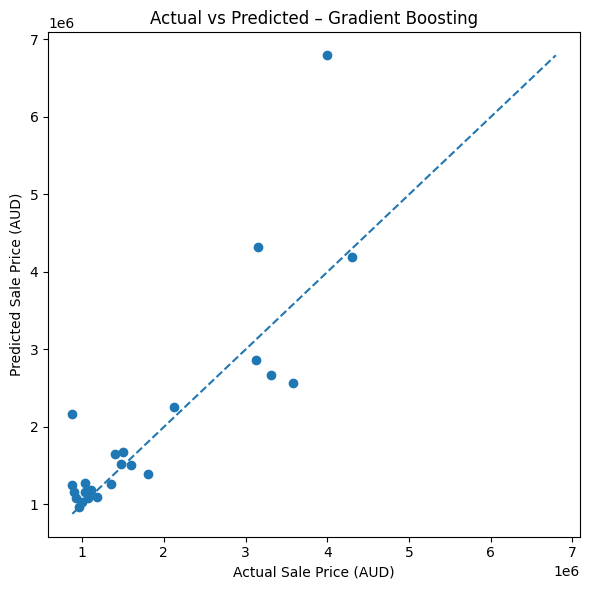

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
lo=min(y_test.min(),pred.min()); hi=max(y_test.max(),pred.max())
plt.plot([lo,hi],[lo,hi],'--')
plt.xlabel('Actual Sale Price (AUD)')
plt.ylabel('Predicted Sale Price (AUD)')
plt.title(f'Actual vs Predicted – {best_name}')
plt.tight_layout()
plt.show()

## 5. Ten held-out properties for ML / LLM / human comparison
The table below provides ten held-out properties and the model predictions. The LLM and human estimates should be recorded separately before comparing them with the actual sale prices.

In [9]:
held10 = error_table.head(10).copy()
held10.insert(len(held10.columns)-2, 'ML_Prediction', held10.pop('Predicted_Price'))
display(held10[['Address','Suburb','Property_Type','Bedrooms','Bathrooms','Parking','Land_Area_sqm','ML_Prediction','Sale_Price_AUD']].style.format({'ML_Prediction':'${:,.0f}','Sale_Price_AUD':'${:,.0f}'}))

,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Land_Area_sqm,ML_Prediction,Sale_Price_AUD
44,302/114 Elliott Street,Balmain,Apartment / Unit / Flat,1,1,1,nan,"$1,094,158","$1,180,000"
47,9/19 Glassop Street,Balmain,Apartment / Unit / Flat,2,1,1,nan,"$1,255,796","$880,000"
4,6 Oregon Street,Blacktown,House,3,1,3,739.000000,"$1,191,549","$1,105,000"
55,15 Bradford Street,Balmain,House,3,1,0,219.000000,"$2,256,749","$2,125,000"
26,41 Burrell Parade,Blacktown,House,3,1,2,556.000000,"$970,759","$960,000"
64,311/22 Colgate Avenue,Balmain,Apartment / Unit / Flat,2,2,1,nan,"$1,397,319","$1,800,000"
73,7 Short Street,Balmain,House,4,3,0,241.000000,"$4,192,641","$4,300,000"
10,17 Carinya Street,Blacktown,House,3,1,1,1182.000000,"$1,513,762","$1,600,000"
40,80 College Street,Balmain,House,5,2,1,334.000000,"$2,572,336","$3,585,000"
107,91 Birriga Road,Bellevue Hill,House,4,2,1,nan,"$6,796,342","$4,000,000"


## 6. Notes for deployment
The Streamlit application uses the same feature set and Gradient Boosting workflow. It retrains the model from the project CSV when the app starts, then accepts property details and returns an estimated sale price. The application is intended as a decision-support demonstration, not a professional valuation service.